Step 1 - Environment Setup – PyBullet

In [2]:
!pip install pybullet numpy matplotlib
!pip uninstall -y dopamine-rl
!pip install stable-baselines3[extra] gym==0.26.2 pybullet --quiet


Basic Flat Terrain Simulation in PyBullet (Headless) and Heightfield Terrain + Robot Movement

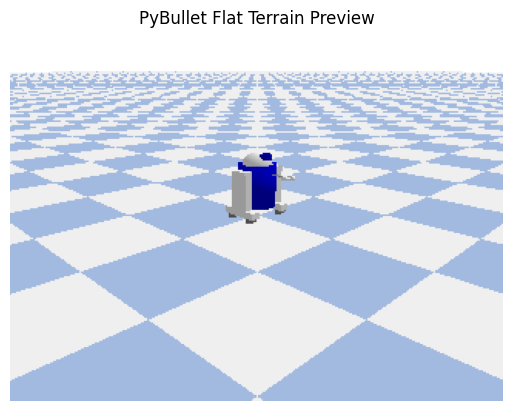

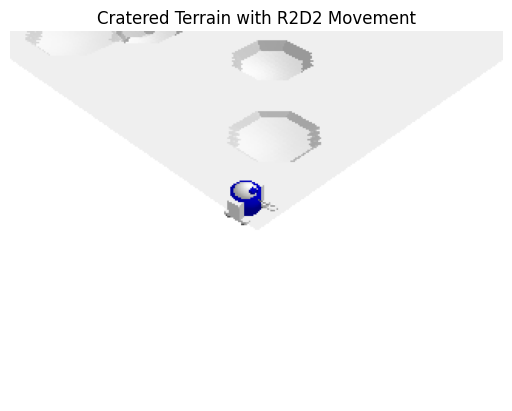

In [4]:
#Step 2: Simulate in PyBullet (DIRECT mode) and capture frames
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Connecting in headless mode (There is no GUI in Colab)
client = p.connect(p.DIRECT)
p.setGravity(0, 0, -9.8)
p.setAdditionalSearchPath(pybullet_data.getDataPath())

# Loading the environment and agent
planeId = p.loadURDF("plane.urdf")
startPos = [0, 0, 0.5]
startOrientation = p.getQuaternionFromEuler([0, 0, 0])
robotId = p.loadURDF("r2d2.urdf", startPos, startOrientation)

# Here is the Camera setup
viewMatrix = p.computeViewMatrix(
    cameraEyePosition=[3, 3, 2],
    cameraTargetPosition=[0, 0, 0],
    cameraUpVector=[0, 0, 1]
)
projectionMatrix = p.computeProjectionMatrixFOV(
    fov=60, aspect=1.0, nearVal=0.1, farVal=100
)

# Step simulation & capturing the frames
frames = []
for step in range(100):
    p.stepSimulation()
    if step % 10 == 0:
        width, height, rgbImg, depthImg, segImg = p.getCameraImage(
            width=320, height=240,
            viewMatrix=viewMatrix,
            projectionMatrix=projectionMatrix
        )
        frames.append(rgbImg)
p.disconnect()

#Step 3: Display captured frame (That will be last image captured)
plt.imshow(frames[-1])
plt.title("PyBullet Flat Terrain Preview")
plt.axis("off")
plt.show()

# Connecting to PyBullet in headless mode
client = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.8)

# Creating craters terrain using heightfield
terrain_shape = 128
heightfield_data = np.zeros(terrain_shape * terrain_shape)

# Adding craters using Gaussian dips
def add_crater(heightfield, center_x, center_y, radius, depth):
    for y in range(terrain_shape):
        for x in range(terrain_shape):
            dx = x - center_x
            dy = y - center_y
            distance = np.sqrt(dx**2 + dy**2)
            if distance < radius:
                heightfield[y * terrain_shape + x] -= depth * np.exp(-(distance**2) / (2 * (radius**2)))

# Generating random craters
np.random.seed(42)
for _ in range(15):
    cx, cy = np.random.randint(10, 118, 2)
    r = np.random.randint(5, 10)
    d = np.random.uniform(0.2, 0.6)
    add_crater(heightfield_data, cx, cy, r, d)

terrain_id = p.createCollisionShape(
    shapeType=p.GEOM_HEIGHTFIELD,
    meshScale=[0.1, 0.1, 1],
    heightfieldTextureScaling=terrain_shape / 2,
    heightfieldData=heightfield_data.tolist(),
    numHeightfieldRows=terrain_shape,
    numHeightfieldColumns=terrain_shape
)
terrain = p.createMultiBody(0, terrain_id)

# Adding a visual texture
p.changeVisualShape(terrain, -1, textureUniqueId=-1)

# Loading a simple robot (R2D2 as placeholder)
start_pos = [6.0, 6.0, 1.0]
robot = p.loadURDF("r2d2.urdf", start_pos, p.getQuaternionFromEuler([0, 0, 0]))

# Moving robot using simple forward motion and rotation
for step in range(100):
    linear_velocity = [0.5, 0, 0]  # forward
    angular_velocity = [0, 0, 0.3]  # slight yaw

    # Applying movement
    p.resetBaseVelocity(robot, linearVelocity=linear_velocity, angularVelocity=angular_velocity)
    p.stepSimulation()

# Camera setup
view_matrix = p.computeViewMatrix(cameraEyePosition=[8, 8, 6],
                                  cameraTargetPosition=[6, 6, 0],
                                  cameraUpVector=[0, 0, 1])
proj_matrix = p.computeProjectionMatrixFOV(fov=60, aspect=1.0, nearVal=0.1, farVal=100)

# Capture final frame
_, _, rgb_img, _, _ = p.getCameraImage(320, 240, view_matrix, proj_matrix)

p.disconnect()

plt.imshow(rgb_img)
plt.title("Cratered Terrain with R2D2 Movement")
plt.axis("off")
plt.show()


Custom Rover + Coverage Tracking

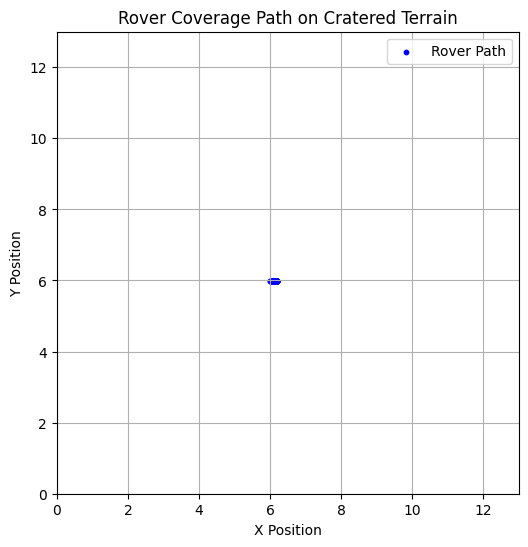

In [34]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.8)

#Creating the cratered terrain
terrain_shape = 128
heightfield_data = np.zeros(terrain_shape * terrain_shape)

def add_crater(heightfield, cx, cy, radius, depth):
    for y in range(terrain_shape):
        for x in range(terrain_shape):
            dx = x - cx
            dy = y - cy
            distance = np.sqrt(dx**2 + dy**2)
            if distance < radius:
                heightfield[y * terrain_shape + x] -= depth * np.exp(-(distance**2) / (2 * radius**2))

np.random.seed(42)
for _ in range(15):
    cx, cy = np.random.randint(10, 118, 2)
    r = np.random.randint(5, 10)
    d = np.random.uniform(0.2, 0.6)
    add_crater(heightfield_data, cx, cy, r, d)

terrain_id = p.createCollisionShape(
    shapeType=p.GEOM_HEIGHTFIELD,
    meshScale=[0.1, 0.1, 1],
    heightfieldTextureScaling=terrain_shape / 2,
    heightfieldData=heightfield_data.tolist(),
    numHeightfieldRows=terrain_shape,
    numHeightfieldColumns=terrain_shape
)
terrain = p.createMultiBody(0, terrain_id)

# This is the Custom Rover Agent (capsule body)
rover_shape = p.createCollisionShape(shapeType=p.GEOM_CAPSULE, radius=0.2, height=0.5)
rover_visual = p.createVisualShape(shapeType=p.GEOM_CAPSULE, radius=0.2, length=0.5, rgbaColor=[0.2, 0.5, 0.8, 1])
rover = p.createMultiBody(baseMass=1,
                          baseCollisionShapeIndex=rover_shape,
                          baseVisualShapeIndex=rover_visual,
                          basePosition=[6.0, 6.0, 1.0])

#Now to Simulate & track position
positions = []

for step in range(100):
    # Applying forward + rotating motion
    p.resetBaseVelocity(rover, linearVelocity=[0.5, 0, 0], angularVelocity=[0, 0, 0.3])
    p.stepSimulation()

    # Track (x, y) position
    pos, _ = p.getBasePositionAndOrientation(rover)
    positions.append((pos[0], pos[1]))

p.disconnect()

positions = np.array(positions)
x_vals, y_vals = positions[:, 0], positions[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(x_vals, y_vals, c='blue', s=10, label='Rover Path')
plt.xlim(0, 13)
plt.ylim(0, 13)
plt.grid(True)
plt.title("Rover Coverage Path on Cratered Terrain")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


Step 2: PPO Agent Baseline Setup 2.1- LunarRoverEnv with Observation Extraction

In [52]:
import gym
from gym import spaces
import numpy as np
import pybullet as p
import pybullet_data

class LunarRoverEnv(gym.Env):
    def __init__(self, render=False):
        super(LunarRoverEnv, self).__init__()

        self.render_mode = render
        self.client = p.connect(p.GUI if render else p.DIRECT)
        p.setGravity(0, 0, -9.8, physicsClientId=self.client)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())

        #This is the Observation space: [x, y, vx, vy, yaw, terrain_z]
        obs_high = np.array([np.inf] * 6, dtype=np.float32)
        self.observation_space = spaces.Box(low=-obs_high, high=obs_high, dtype=np.float32)

        #This is the Temporary action space (will update in Step 2.2)
        self.action_space = spaces.Box(low=np.array([-1.0, -1.0]), high=np.array([1.0, 1.0]), dtype=np.float32)

        #This is for the Terrain parameters
        self.terrain_shape = 128
        self._create_terrain()

        # Rover
        self.rover = self._create_rover()

    def _create_terrain(self):
        # Generating procedural cratered heightfield
        terrain_data = np.zeros(self.terrain_shape * self.terrain_shape)
        for _ in range(10):
            cx, cy = np.random.randint(10, 118, 2)
            r = np.random.randint(5, 10)
            d = np.random.uniform(0.2, 0.6)
            for y in range(self.terrain_shape):
                for x in range(self.terrain_shape):
                    dx, dy = x - cx, y - cy
                    dist = np.sqrt(dx**2 + dy**2)
                    if dist < r:
                        terrain_data[y * self.terrain_shape + x] -= d * np.exp(-(dist**2) / (2 * r**2))

        # Loading terrain in PyBullet
        self.terrain_id = p.createCollisionShape(
            shapeType=p.GEOM_HEIGHTFIELD,
            meshScale=[0.1, 0.1, 1],
            heightfieldTextureScaling=self.terrain_shape / 2,
            heightfieldData=terrain_data.tolist(),
            numHeightfieldRows=self.terrain_shape,
            numHeightfieldColumns=self.terrain_shape
        )
        self.terrain = p.createMultiBody(0, self.terrain_id)

    def _create_rover(self):
        # The rover body is a simple capsule
        shape = p.createCollisionShape(p.GEOM_CAPSULE, radius=0.2, height=0.5)
        visual = p.createVisualShape(p.GEOM_CAPSULE, radius=0.2, length=0.5, rgbaColor=[0.2, 0.5, 0.8, 1])
        return p.createMultiBody(baseMass=1, baseCollisionShapeIndex=shape,
                                 baseVisualShapeIndex=visual, basePosition=[6, 6, 1])

    def reset(self):
        p.resetSimulation(physicsClientId=self.client)
        p.setGravity(0, 0, -9.8, physicsClientId=self.client)
        self._create_terrain()
        self.rover = self._create_rover()
        return self._get_observation()

    def _get_observation(self):
        # Extracting position, orientation and velocity
        pos, orn = p.getBasePositionAndOrientation(self.rover)
        lin_vel, _ = p.getBaseVelocity(self.rover)
        x, y, z = pos
        vx, vy, _ = lin_vel
        yaw = p.getEulerFromQuaternion(orn)[2]
        return np.array([x, y, vx, vy, yaw, z], dtype=np.float32)

#Step 2.2 – Defining Action Space + Applying Actions
    def step(self, action):
    # Scaling actions to physical motion
      max_speed = 1.0    # meters per second
      max_turn = 1.0     # radians per second

      speed = float(np.clip(action[0], -1, 1)) * max_speed
      turn_rate = float(np.clip(action[1], -1, 1)) * max_turn

    # Applying linear and angular velocity
      p.resetBaseVelocity(
          self.rover,
          linearVelocity=[speed, 0, 0],
          angularVelocity=[0, 0, turn_rate]
      )

      # Simulate one step
      p.stepSimulation(physicsClientId=self.client)

      # Get next state
      obs = self._get_observation()

      # Simple reward: forward movement (we can check and it can be improved later)
      reward = speed * 0.5

      # Episode done if rover goes out of bounds (It can be optional)
      x, y, _, _, _, _ = obs
      done = x < 0 or x > 12.8 or y < 0 or y > 12.8

      return obs, reward, done, {}


    def render(self, mode='human'):
        pass

    def close(self):
        p.disconnect(self.client)

#Testing Updated Step Logic
env = LunarRoverEnv(render=False)
obs = env.reset()

for _ in range(10):
    action = env.action_space.sample()  # This is random throttle/turn
    obs, reward, done, info = env.step(action)
    print("Obs:", obs, "Reward:", reward)


Obs: [6.         6.         0.25023082 0.         0.         1.        ] Reward: 0.12511540949344635
Obs: [ 6.          6.         -0.25140423  0.          0.          1.        ] Reward: -0.1257021129131317
Obs: [ 6.         6.        -0.4178638  0.         0.         1.       ] Reward: -0.20893189311027527
Obs: [ 6.         6.        -0.9866924  0.         0.         1.       ] Reward: -0.4933462142944336
Obs: [ 6.         6.        -0.6794018  0.         0.         1.       ] Reward: -0.3397009074687958
Obs: [6.      6.      0.96594 0.      0.      1.     ] Reward: 0.4829699993133545
Obs: [ 6.         6.        -0.6334798  0.         0.         1.       ] Reward: -0.31673988699913025
Obs: [6.         6.         0.96916205 0.         0.         1.        ] Reward: 0.48458102345466614
Obs: [ 6.          6.         -0.12041867  0.          0.          1.        ] Reward: -0.06020933389663696
Obs: [ 6.          6.         -0.84687823  0.          0.          1.        ] Reward: -0.42343

Implement Reward in step() Method

In [44]:
import gym
from gym import spaces
import numpy as np
import pybullet as p
import pybullet_data

class LunarRoverEnv(gym.Env):
    def __init__(self, render=False):
        super(LunarRoverEnv, self).__init__()

        self.render_mode = render
        self.client = p.connect(p.GUI if render else p.DIRECT)
        p.setGravity(0, 0, -9.8, physicsClientId=self.client)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())

        obs_high = np.array([np.inf] * 6, dtype=np.float32)
        self.observation_space = spaces.Box(low=-obs_high, high=obs_high, dtype=np.float32)
        self.action_space = spaces.Box(low=np.array([-1.0, -1.0]), high=np.array([1.0, 1.0]), dtype=np.float32)
        self.terrain_shape = 128
        self._create_terrain()
        self.rover = self._create_rover()

    def _create_terrain(self):
        terrain_data = np.zeros(self.terrain_shape * self.terrain_shape)
        for _ in range(10):
            cx, cy = np.random.randint(10, 118, 2)
            r = np.random.randint(5, 10)
            d = np.random.uniform(0.2, 0.6)
            for y in range(self.terrain_shape):
                for x in range(self.terrain_shape):
                    dx, dy = x - cx, y - cy
                    dist = np.sqrt(dx**2 + dy**2)
                    if dist < r:
                        terrain_data[y * self.terrain_shape + x] -= d * np.exp(-(dist**2) / (2 * r**2))
        self.terrain_id = p.createCollisionShape(
            shapeType=p.GEOM_HEIGHTFIELD,
            meshScale=[0.1, 0.1, 1],
            heightfieldTextureScaling=self.terrain_shape / 2,
            heightfieldData=terrain_data.tolist(),
            numHeightfieldRows=self.terrain_shape,
            numHeightfieldColumns=self.terrain_shape
        )
        self.terrain = p.createMultiBody(0, self.terrain_id)

    def _create_rover(self):
        shape = p.createCollisionShape(p.GEOM_CAPSULE, radius=0.2, height=0.5)
        visual = p.createVisualShape(p.GEOM_CAPSULE, radius=0.2, length=0.5, rgbaColor=[0.2, 0.5, 0.8, 1])
        return p.createMultiBody(baseMass=1, baseCollisionShapeIndex=shape,
                                 baseVisualShapeIndex=visual, basePosition=[6, 6, 1])

    def reset(self):
        p.resetSimulation(physicsClientId=self.client)
        p.setGravity(0, 0, -9.8, physicsClientId=self.client)
        self._create_terrain()
        self.rover = self._create_rover()
        return self._get_observation()

    def _get_observation(self):
        pos, orn = p.getBasePositionAndOrientation(self.rover)
        lin_vel, _ = p.getBaseVelocity(self.rover)
        x, y, z = pos
        vx, vy, _ = lin_vel
        yaw = p.getEulerFromQuaternion(orn)[2]
        return np.array([x, y, vx, vy, yaw, z], dtype=np.float32)

    def step(self, action):
      max_speed = 1.0
      max_turn = 1.0

      # Scale action
      speed = float(np.clip(action[0], -1, 1)) * max_speed
      turn_rate = float(np.clip(action[1], -1, 1)) * max_turn

      # Apply motion
      p.resetBaseVelocity(self.rover, [speed, 0, 0], [0, 0, turn_rate])
      p.stepSimulation()

      # Observation
      obs = self._get_observation()
      x, y, vx, vy, yaw, z = obs

      #These are the Reward Components
      current_pos = np.array([x, y])
      distance_delta = np.linalg.norm(current_pos - getattr(self, "last_pos", current_pos))
      self.last_pos = current_pos

      # This is for the Coverage bonus
      cell_x, cell_y = int(x), int(y)
      cell_key = (cell_x, cell_y)
      visited_before = getattr(self, "visited", set())
      if cell_key not in visited_before:
          coverage_bonus = 1.0
          visited_before.add(cell_key)
      else:
          coverage_bonus = 0.0
      self.visited = visited_before

      # Idle penalty
      idle_penalty = 0.1 if np.abs(speed) < 0.05 else 0.0

      # Total reward
      reward = distance_delta * 1.0 + coverage_bonus * 0.5 - idle_penalty

      # if out of bounds than done
      done = x < 0 or x > 12.8 or y < 0 or y > 12.8

      return obs, reward, done, {}

    def render(self, mode='human'):
        pass

    def close(self):
        p.disconnect(self.client)

#Testing the steps

# Instantiate environment
env = LunarRoverEnv(render=False)
obs = env.reset()
print("Initial Observation:", obs)

# Run a short test rollout
total_reward = 0.2
for step in range(10):
    action = env.action_space.sample()  # random action
    obs, reward, done, _ = env.step(action)

    print(f"Step {step + 1}")
    print("  Observation:", obs)
    print("  Reward:", reward)
    print("  Done:", done)

    total_reward += reward
    if done:
        print("Episode ended early due to boundary condition.")
        break

print("\nTotal Reward Collected:", total_reward)
print("Cells Visited (coverage):", len(env.visited))



Initial Observation: [6. 6. 0. 0. 0. 1.]
Step 1
  Observation: [ 5.9856343   6.102949   -3.447778   24.707777    0.03044263  1.0321517 ]
  Reward: 0.5
  Done: False
Step 2
  Observation: [ 5.9812436   6.136986   -1.0537528   8.168805    0.03518081  1.0430417 ]
  Reward: 0.034318667
  Done: False
Step 3
  Observation: [ 5.9687433   6.1551757  -3.0000594   4.365629    0.05698775  1.047988  ]
  Reward: 0.022071019
  Done: False
Step 4
  Observation: [ 5.9679046   6.156737   -0.20134726  0.37460208  0.06043307  1.048585  ]
  Reward: 0.0017722156
  Done: False
Step 5
  Observation: [ 5.9660916   6.158415   -0.43508208  0.402784    0.06754248  1.0489484 ]
  Reward: 0.0024703
  Done: False
Step 6
  Observation: [ 5.9635134   6.1586504  -0.6187257   0.05652382  0.06989257  1.0491538 ]
  Reward: 0.0025889967
  Done: False
Step 7
  Observation: [ 5.961916    6.1622577  -0.3834068   0.86575764  0.07888156  1.0491921 ]
  Reward: 0.003945139
  Done: False
Step 8
  Observation: [5.9619994  6.1660724

PPO Integration with Stable-Baselines3

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 763  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 623         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006329885 |
|    clip_fraction        | 0.066       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.84       |
|    explained_variance   | -0.248      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0144     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00533    |
|    std                  | 1           |
|    value_loss           | 0.00468     |
-----------------

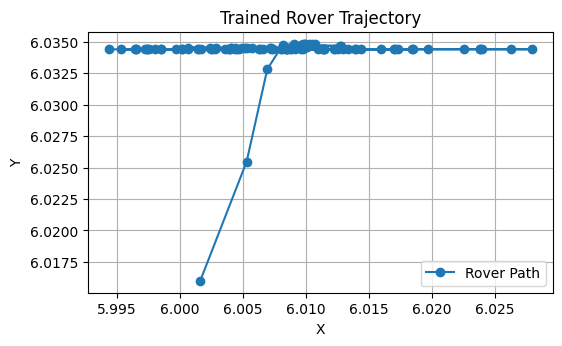

Total Reward by Trained Agent: 0.9639637673296231
Unique Cells Visited: 2


In [45]:
!pip install stable-baselines3[extra] gym matplotlib --quiet
!pip install 'shimmy>=2.0'
import gym
from gym import spaces
import numpy as np
import pybullet as p
import pybullet_data
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt

class LunarRoverEnv(gym.Env):
    def __init__(self, render=False):
        super(LunarRoverEnv, self).__init__()
        self.render_mode = render
        self.client = p.connect(p.GUI if render else p.DIRECT)
        p.setGravity(0, 0, -9.8, physicsClientId=self.client)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())

        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)
        self.action_space = spaces.Box(low=np.array([-1.0, -1.0]), high=np.array([1.0, 1.0]), dtype=np.float32)

        self.terrain_shape = 128
        self._create_terrain()
        self.rover = self._create_rover()

    def _create_terrain(self):
        terrain_data = np.zeros(self.terrain_shape * self.terrain_shape)
        for _ in range(10):
            cx, cy = np.random.randint(10, 118, 2)
            r = np.random.randint(5, 10)
            d = np.random.uniform(0.2, 0.6)
            for y in range(self.terrain_shape):
                for x in range(self.terrain_shape):
                    dx, dy = x - cx, y - cy
                    dist = np.sqrt(dx**2 + dy**2)
                    if dist < r:
                        terrain_data[y * self.terrain_shape + x] -= d * np.exp(-(dist**2) / (2 * r**2))

        self.terrain_id = p.createCollisionShape(
            shapeType=p.GEOM_HEIGHTFIELD,
            meshScale=[0.1, 0.1, 1],
            heightfieldTextureScaling=self.terrain_shape / 2,
            heightfieldData=terrain_data.tolist(),
            numHeightfieldRows=self.terrain_shape,
            numHeightfieldColumns=self.terrain_shape
        )
        self.terrain = p.createMultiBody(0, self.terrain_id)

    def _create_rover(self):
        shape = p.createCollisionShape(p.GEOM_CAPSULE, radius=0.2, height=0.5)
        visual = p.createVisualShape(p.GEOM_CAPSULE, radius=0.2, length=0.5, rgbaColor=[0.2, 0.5, 0.8, 1])
        return p.createMultiBody(baseMass=1, baseCollisionShapeIndex=shape,
                                 baseVisualShapeIndex=visual, basePosition=[6, 6, 1])

    def reset(self):
        p.resetSimulation(physicsClientId=self.client)
        p.setGravity(0, 0, -9.8, physicsClientId=self.client)
        self._create_terrain()
        self.rover = self._create_rover()
        self.last_pos = np.array([6.0, 6.0])
        self.visited = set()
        return self._get_observation()

    def _get_observation(self):
        pos, orn = p.getBasePositionAndOrientation(self.rover)
        lin_vel, _ = p.getBaseVelocity(self.rover)
        x, y, z = pos
        vx, vy, _ = lin_vel
        yaw = p.getEulerFromQuaternion(orn)[2]
        return np.array([x, y, vx, vy, yaw, z], dtype=np.float32)

    def step(self, action):
        max_speed = 1.0
        max_turn = 1.0

        speed = float(np.clip(action[0], -1, 1)) * max_speed
        turn_rate = float(np.clip(action[1], -1, 1)) * max_turn

        p.resetBaseVelocity(self.rover, [speed, 0, 0], [0, 0, turn_rate])
        p.stepSimulation()

        obs = self._get_observation()
        x, y, _, _, _, _ = obs
        current_pos = np.array([x, y])

        distance_delta = np.linalg.norm(current_pos - self.last_pos)
        self.last_pos = current_pos

        cell_x, cell_y = int(x), int(y)
        cell_key = (cell_x, cell_y)
        coverage_bonus = 1.0 if cell_key not in self.visited else 0.0
        self.visited.add(cell_key)

        idle_penalty = 0.1 if np.abs(speed) < 0.05 else 0.0

        reward = distance_delta * 1.0 + coverage_bonus * 0.5 - idle_penalty
        done = x < 0 or x > 12.8 or y < 0 or y > 12.8

        return obs, reward, done, {}

    def render(self, mode='human'):
        pass

    def close(self):
        p.disconnect(self.client)

# Create=ing and wrapping the environment
env = DummyVecEnv([lambda: LunarRoverEnv(render=False)])

# Training PPO model
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=5000)

# Evaluating trained model
test_env = LunarRoverEnv(render=False)
obs = test_env.reset()
total_reward = 0.0
positions = []

for _ in range(100):
    action, _states = model.predict(obs)
    obs, reward, done, _ = test_env.step(action)
    x, y, *_ = obs
    positions.append((x, y))
    total_reward += reward
    if done:
        break

test_env.close()

# Plotting the trajectory
positions = np.array(positions)
plt.figure(figsize=(6, 6))
plt.plot(positions[:, 0], positions[:, 1], marker='o', label="Rover Path")
plt.title("Trained Rover Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal')
plt.show()
print("Total Reward by Trained Agent:", total_reward)
print("Unique Cells Visited:", len(set((int(x), int(y)) for x, y in positions)))


Step 3.1: Add Intrinsic Curiosity Module (ICM)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import gym
import random
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

#SECTION 2: ICM Model Architecture and Replay Buffer
class FeatureEncoder(nn.Module):
    def __init__(self, obs_dim, feature_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, feature_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class InverseModel(nn.Module):
    def __init__(self, feature_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(2 * feature_dim, 256)
        self.fc2 = nn.Linear(256, action_dim)

    def forward(self, f1, f2):
        x = torch.cat([f1, f2], dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class ForwardModel(nn.Module):
    def __init__(self, feature_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(feature_dim + action_dim, 256)
        self.fc2 = nn.Linear(256, feature_dim)

    def forward(self, f1, a):
        x = torch.cat([f1, a], dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class ICM(nn.Module):
    def __init__(self, obs_dim, action_dim, feature_dim=128, beta=0.2):
        super().__init__()
        self.beta = beta
        self.encoder = FeatureEncoder(obs_dim, feature_dim)
        self.inverse = InverseModel(feature_dim, action_dim)

        self.forward_model = ForwardModel(feature_dim, action_dim)
        self.mse = nn.MSELoss(reduction='none')

    def forward(self, obs, next_obs, actions):
        phi = self.encoder(obs)
        phi_next = self.encoder(next_obs)
        pred_actions = self.inverse(phi, phi_next)
        inv_loss = self.mse(pred_actions, actions).mean()
        pred_phi_next = self.forward_model(phi, actions)
        fwd_loss_per_sample = self.mse(pred_phi_next, phi_next).mean(dim=1)
        fwd_loss = fwd_loss_per_sample.mean()

        intrinsic_reward = fwd_loss_per_sample.detach()
        icm_loss = (1 - self.beta) * inv_loss + self.beta * fwd_loss

        return intrinsic_reward, icm_loss

class ICMReplayBuffer:
    def __init__(self, buffer_size, obs_dim, action_dim, device='cpu'):
        self.obs_buf = np.zeros((buffer_size, obs_dim), dtype=np.float32)
        self.next_obs_buf = np.zeros((buffer_size, obs_dim), dtype=np.float32)
        self.actions_buf = np.zeros((buffer_size, action_dim), dtype=np.float32)

        self.max_size = buffer_size
        self.ptr = 0
        self.size = 0
        self.device = device

    def add(self, obs, action, next_obs):
        self.obs_buf[self.ptr] = obs
        self.actions_buf[self.ptr] = action
        self.next_obs_buf[self.ptr] = next_obs
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idxs = np.random.choice(self.size, batch_size, replace=False)
        obs = torch.tensor(self.obs_buf[idxs], dtype=torch.float32).to(self.device)
        actions = torch.tensor(self.actions_buf[idxs], dtype=torch.float32).to(self.device)
        next_obs = torch.tensor(self.next_obs_buf[idxs], dtype=torch.float32).to(self.device)
        return obs, actions, next_obs

    def __len__(self):
        return self.size

#SECTION 3: Data Collection with Intrinsic Rewards (Using Rollout Function)

def collect_rollouts_with_icm(env, model, icm, icm_buffer, eta=0.02, device='cpu', rollout_steps=8192):
    obs = env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]
    done = False

    for _ in range(rollout_steps):
        #Converting the observation to tensor
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)

        #Predicting action from PPO
        action, _ = model.predict(obs, deterministic=False)
        action = np.array(action).flatten()  # Ensure shape: (action_dim,)
        actions_tensor = torch.tensor(action, dtype=torch.float32).unsqueeze(0).to(device)

        #Taking step in environment
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        if isinstance(next_obs, tuple):
            next_obs = next_obs[0]
        next_obs_tensor = torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0).to(device)

        #Storing to ICM buffer
        icm_buffer.add(obs, action, next_obs)

        #Compute intrinsic reward with all 3 args
        with torch.no_grad():
            intrinsic_reward, _ = icm (obs_tensor, next_obs_tensor, actions_tensor)

        total_reward = reward + eta * intrinsic_reward.item()

        #Moving to next step
        obs = next_obs
        if done:
            obs = env.reset()
            if isinstance(obs, tuple):
                obs = obs[0]

#SECTION 4: ICM Training Function
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

def train_icm(icm, icm_buffer, icm_optimizer, batch_size=64, icm_epochs=4):
    icm.train()
    total_loss = 0

    for epoch in range(icm_epochs):
        if len(icm_buffer) < batch_size:
            break

        obs, actions, next_obs = icm_buffer.sample(batch_size)

        # Forward pass through ICM
        intrinsic_reward, icm_loss = icm(obs, next_obs, actions)

        # Backward and optimize
        icm_optimizer.zero_grad()
        icm_loss.backward()
        icm_optimizer.step()

        total_loss += icm_loss.item()

    avg_loss = total_loss / max(1, icm_epochs)
    return avg_loss

#SECTION 5: PPO and ICM Combined Training Loop

env = gym.make("MountainCarContinuous-v0")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

# Initializing PPO and ICM
ppo_model = PPO("MlpPolicy", DummyVecEnv([lambda: env]), verbose=0)
icm = ICM(obs_dim, action_dim).to(device)
icm_optimizer = torch.optim.Adam(icm.parameters(), lr=1e-3)
icm_buffer = ICMReplayBuffer(buffer_size=10000, obs_dim=obs_dim, action_dim=action_dim, device=device)

n_iterations = 20
rollout_steps = 8192

for it in range(n_iterations):
    print(f"\n=== Iteration {it+1} ===")

    # 1. Collecting rollouts and compute intrinsic reward
    collect_rollouts_with_icm (env, ppo_model, icm, icm_buffer, eta=0.02, device='cpu', rollout_steps=8192)

    # 2. Training ICM
    icm_loss = train_icm(icm, icm_buffer, icm_optimizer)
    print(f"ICM Loss: {icm_loss:.4f}")

    # 3. Training PPO on updated environment dynamics
    ppo_model.learn(total_timesteps=rollout_steps)

#SECTION 6: Logging ICM Loss Over Iterations

#Track ICM loss manually
icm_loss_log = []

# Modified training loop to include logging
n_iterations = 10
for it in range(n_iterations):
    print(f"\n=== Iteration {it+1} ===")

    collect_rollouts_with_icm(env, ppo_model, icm, icm_buffer, eta=0.02, device='cpu', rollout_steps=8192)

    icm_loss = train_icm(icm, icm_buffer, icm_optimizer)
    icm_loss_log.append(icm_loss)
    print(f"ICM Loss: {icm_loss:.4f}")

    ppo_model.learn(total_timesteps=2048)

plt.plot(range(1, len(icm_loss_log) + 1), icm_loss_log, marker='o')
plt.title("ICM Loss over Training Iterations")
plt.xlabel("Iteration")
plt.ylabel("ICM Loss")
plt.grid(True)
plt.show()



=== Iteration 1 ===
ICM Loss: 0.4238

=== Iteration 2 ===
ICM Loss: 0.3652

=== Iteration 3 ===
ICM Loss: 0.2529

=== Iteration 4 ===
ICM Loss: 0.1408

=== Iteration 5 ===
ICM Loss: 0.0590

=== Iteration 6 ===
ICM Loss: 0.0399

=== Iteration 7 ===
ICM Loss: 0.0202

=== Iteration 8 ===
ICM Loss: 0.0105

=== Iteration 9 ===
ICM Loss: 0.0074

=== Iteration 10 ===
ICM Loss: 0.0048

=== Iteration 11 ===
ICM Loss: 0.0028

=== Iteration 12 ===
ICM Loss: 0.0018

=== Iteration 13 ===
ICM Loss: 0.0012

=== Iteration 14 ===
ICM Loss: 0.0007

=== Iteration 15 ===
ICM Loss: 0.0004


Step 4.1: Track and Log Rover Trajectories

In [ ]:
def collect_rollouts_with_icm(env, model, icm, icm_buffer, eta=0.02, device='cpu', rollout_steps=8192):
    obs = env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]
    done = False

    trajectory = []

    for _ in range(rollout_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)

        action, _ = model.predict(obs, deterministic=False)
        action_arr = np.array(action).flatten()
        action_tensor = torch.tensor(action_arr, dtype=torch.float32).unsqueeze(0).to(device)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        if isinstance(next_obs, tuple):
            next_obs = next_obs[0]
        next_obs_tensor = torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0).to(device)

        icm_buffer.add(obs, action_arr, next_obs)

        with torch.no_grad():
            intrinsic_reward, _ = icm(obs_tensor, next_obs_tensor, action_tensor)

        total_reward = reward + eta * intrinsic_reward.item()

        #Tracking position (first 2 dims in MountainCarContinuous)
        trajectory.append((obs[0], obs[1]))

        obs = next_obs
        if done:
            obs = env.reset()
            if isinstance(obs, tuple):
                obs = obs[0]

    return trajectory

#SECTION 4: ICM Training Function

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

def train_icm(icm, icm_buffer, icm_optimizer, batch_size=64, icm_epochs=4):
    icm.train()
    total_loss = 0

    for epoch in range(icm_epochs):
        if len(icm_buffer) < batch_size:
            break

        obs, actions, next_obs = icm_buffer.sample(batch_size)
        intrinsic_reward, icm_loss = icm(obs, next_obs, actions)
        icm_optimizer.zero_grad()
        icm_loss.backward()
        icm_optimizer.step()

        total_loss += icm_loss.item()

    avg_loss = total_loss / max(1, icm_epochs)
    return avg_loss

#SECTION 5: PPO and ICM Combined Training Loop


env = gym.make("MountainCarContinuous-v0")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
ppo_model = PPO("MlpPolicy", DummyVecEnv([lambda: env]), verbose=0)
icm = ICM(obs_dim, action_dim).to(device)
icm_optimizer = torch.optim.Adam(icm.parameters(), lr=1e-3)
icm_buffer = ICMReplayBuffer(buffer_size=10000, obs_dim=obs_dim, action_dim=action_dim, device=device)


n_iterations = 20
rollout_steps = 8192

for it in range(n_iterations):
    print(f"\n=== Iteration {it+1} ===")

    collect_rollouts_with_icm (env, ppo_model, icm, icm_buffer, eta=0.02, device='cpu', rollout_steps=8192)
    icm_loss = train_icm(icm, icm_buffer, icm_optimizer)
    print(f"ICM Loss: {icm_loss:.4f}")
    ppo_model.learn(total_timesteps=rollout_steps)


trajectory = collect_rollouts_with_icm(env, ppo_model, icm, icm_buffer, eta=0.02, device=device, rollout_steps=8192)
trajectory = np.array(trajectory)

plt.figure(figsize=(10, 4))
plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', linewidth=1)
plt.title("Rover Trajectory over Terrain")
plt.xlabel("Position X")
plt.ylabel("Velocity")
plt.grid(True)
plt.show()


Step 4.2: Plot Intrinsic vs Extrinsic Reward Over Time :- Modify the Rollout Function to Log Rewards


=== Iteration 1 ===
ICM Loss: 0.4155

=== Iteration 2 ===
ICM Loss: 0.3976

=== Iteration 3 ===
ICM Loss: 0.3698

=== Iteration 4 ===
ICM Loss: 0.3279

=== Iteration 5 ===
ICM Loss: 0.2837

=== Iteration 6 ===
ICM Loss: 0.2880

=== Iteration 7 ===
ICM Loss: 0.2178

=== Iteration 8 ===
ICM Loss: 0.1815

=== Iteration 9 ===
ICM Loss: 0.1593

=== Iteration 10 ===
ICM Loss: 0.1442
[Step 0] Ext: -0.0383 | ICM: 0.000417 | Total: -0.0383
[Step 200] Ext: -0.0041 | ICM: 0.000339 | Total: -0.0041
[Step 400] Ext: -0.0094 | ICM: 0.000328 | Total: -0.0094
[Step 600] Ext: -0.0254 | ICM: 0.000435 | Total: -0.0254
[Step 800] Ext: -0.0013 | ICM: 0.000418 | Total: -0.0013
[Step 1000] Ext: -0.0124 | ICM: 0.000486 | Total: -0.0124
[Step 1200] Ext: -0.0014 | ICM: 0.000376 | Total: -0.0014
[Step 1400] Ext: -0.0077 | ICM: 0.000357 | Total: -0.0077
[Step 1600] Ext: -0.0135 | ICM: 0.000562 | Total: -0.0135
[Step 1800] Ext: -0.0177 | ICM: 0.000494 | Total: -0.0176
[Step 2000] Ext: -0.0240 | ICM: 0.000393 | Tot

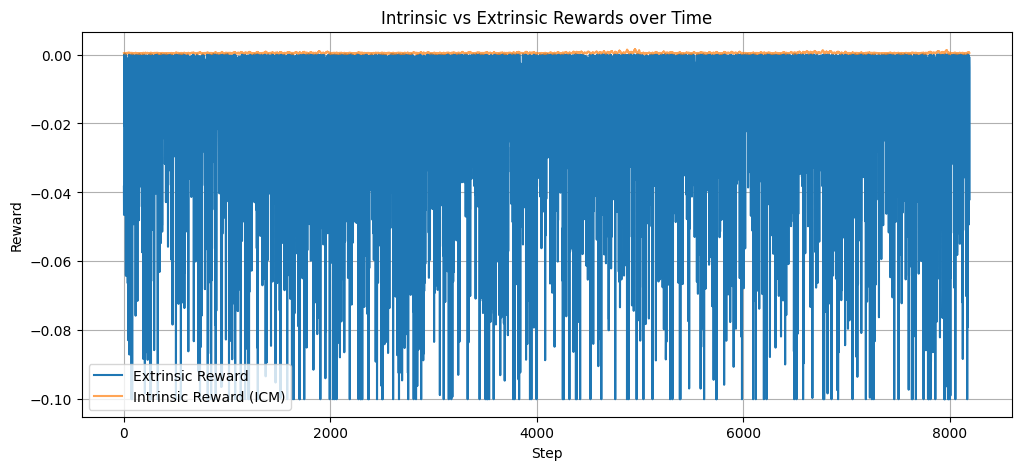

In [48]:
#SECTION 4: ICM Training Function
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

def train_icm(icm, icm_buffer, icm_optimizer, batch_size=64, icm_epochs=4):
    icm.train()
    total_loss = 0

    for epoch in range(icm_epochs):
        if len(icm_buffer) < batch_size:
            break

        obs, actions, next_obs = icm_buffer.sample(batch_size)
        intrinsic_reward, icm_loss = icm(obs, next_obs, actions)
        icm_optimizer.zero_grad()
        icm_loss.backward()
        icm_optimizer.step()

        total_loss += icm_loss.item()

    avg_loss = total_loss / max(1, icm_epochs)
    return avg_loss

#SECTION 5: PPO + ICM Combined Training Loop

env = gym.make("MountainCarContinuous-v0")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

ppo_model = PPO("MlpPolicy", DummyVecEnv([lambda: env]), verbose=0)
icm = ICM(obs_dim, action_dim).to(device)
icm_optimizer = torch.optim.Adam(icm.parameters(), lr=1e-3)
icm_buffer = ICMReplayBuffer(buffer_size=10000, obs_dim=obs_dim, action_dim=action_dim, device=device)

n_iterations = 20
rollout_steps = 8192

for it in range(n_iterations):
    print(f"\n=== Iteration {it+1} ===")

    collect_rollouts_with_icm (env, ppo_model, icm, icm_buffer, eta=0.02, device='cpu', rollout_steps=8192)

    icm_loss = train_icm(icm, icm_buffer, icm_optimizer)
    print(f"ICM Loss: {icm_loss:.4f}")
    ppo_model.learn(total_timesteps=rollout_steps)

def collect_rollouts_with_icm(env, model, icm, icm_buffer, eta=0.02, device='cpu', rollout_steps=8192):
    obs = env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]
    done = False

    trajectory = []            # to track position (x, velocity)
    intrinsic_rewards = []     # to log curiosity-based rewards
    extrinsic_rewards = []     # to log environment rewards

    for step in range(rollout_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
        action, _ = model.predict(obs, deterministic=False)
        action_arr = np.array(action).flatten()
        action_tensor = torch.tensor(action_arr, dtype=torch.float32).unsqueeze(0).to(device)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        if isinstance(next_obs, tuple):
            next_obs = next_obs[0]
        next_obs_tensor = torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0).to(device)

        icm_buffer.add(obs, action_arr, next_obs)

        with torch.no_grad():
            intrinsic_reward, _ = icm(obs_tensor, next_obs_tensor, action_tensor)

        total_reward = reward + eta * intrinsic_reward.item()

        #Track logs
        trajectory.append((obs[0], obs[1]))
        extrinsic_rewards.append(reward)
        intrinsic_rewards.append(intrinsic_reward.item())
        if step % 200 == 0:
            print(f"[Step {step}] Ext: {reward:.4f} | ICM: {intrinsic_reward.item():.6f} | Total: {total_reward:.4f}")

        obs = next_obs
        if done:
            obs = env.reset()
            if isinstance(obs, tuple):
                obs = obs[0]
    print("\n--- Rollout Summary ---")
    print("Trajectory Sample:", trajectory[:3])
    print("Extrinsic Reward Sample:", extrinsic_rewards[:5])
    print("Intrinsic Reward Sample:", intrinsic_rewards[:5])
    print(f"Avg Extrinsic: {np.mean(extrinsic_rewards):.4f}, Max: {np.max(extrinsic_rewards):.4f}")
    print(f"Avg Intrinsic: {np.mean(intrinsic_rewards):.6f}, Max: {np.max(intrinsic_rewards):.6f}")

    return trajectory, extrinsic_rewards, intrinsic_rewards

trajectory, extrinsic_rewards, intrinsic_rewards = collect_rollouts_with_icm(
    env, ppo_model, icm, icm_buffer, eta=0.02, device=device, rollout_steps=8192)

plt.figure(figsize=(12, 5))
plt.plot(extrinsic_rewards, label='Extrinsic Reward')
plt.plot(intrinsic_rewards, label='Intrinsic Reward (ICM)', alpha=0.7)
plt.title("Intrinsic vs Extrinsic Rewards over Time")
plt.xlabel("Step")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()

Step 4.3: Visualize Coverage of Terrain - to Plot Coverage Heatmap

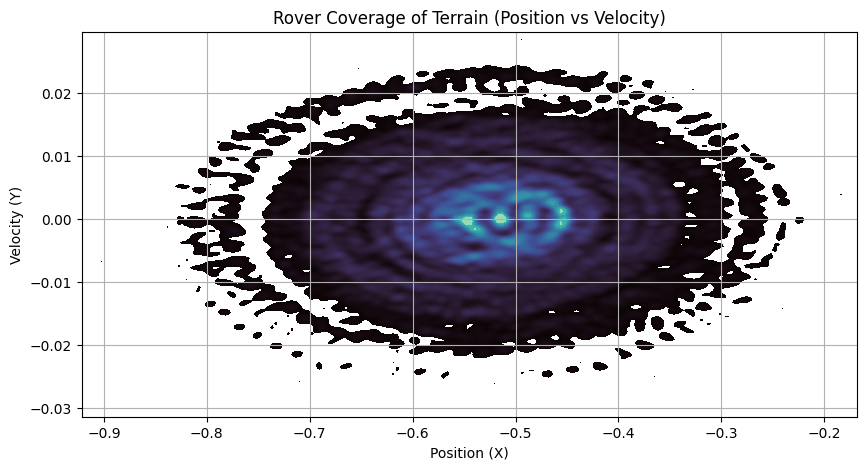

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_coverage_heatmap(trajectory):
    trajectory = np.array(trajectory)
    x = trajectory[:, 0]  # Position
    y = trajectory[:, 1]  # Velocity

    plt.figure(figsize=(10, 5))
    sns.kdeplot(x=x, y=y, fill=True, cmap="mako", bw_adjust=0.2, levels=100, thresh=0.05)
    plt.title("Rover Coverage of Terrain (Position vs Velocity)")
    plt.xlabel("Position (X)")
    plt.ylabel("Velocity (Y)")
    plt.grid(True)
    plt.show()
plot_coverage_heatmap(trajectory)
